# COVID-19 Impact on Flights

### Aim:

To analyze and visualize how the COVID-19 pandemic affected global air travel patterns — including flight frequency, cancellations, and passenger volume — using Python and real-world aviation data. The goal is to compare pre- and post-pandemic trends to understand the extent of disruption and recovery in the aviation industry.

### Description:

The COVID-19 Impact on Flights project focuses on examining how global air traffic changed due to the COVID-19 outbreak. Using real-world flight data, this project analyzes variations in total flights, cancellations, and passenger counts between 2019 (pre-pandemic) and 2020 (pandemic period).

Data cleaning and transformation are performed using Pandas, while Matplotlib and Seaborn are used for creating impactful visualizations that reveal patterns and insights.

The project highlights a significant drop in flight activity and passenger numbers during the early months of 2020, followed by a gradual recovery — showcasing how data analytics can tell powerful stories from real-world events.

### Skills Used:

Python | Pandas | Data Cleaning | Data Aggregation | Visualization (Matplotlib) | Analytical Thinking

### 1️⃣ Import Libraries

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')  # suppress warnings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

### 2️⃣ Load Dataset

In [11]:
df = pd.read_csv('jantojun2020[1].csv', low_memory=False)
print("✅ Dataset Loaded!")
print("Rows & Columns:", df.shape)
print(df.columns)


✅ Dataset Loaded!
Rows & Columns: (2745847, 47)
Index(['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE',
       'MKT_UNIQUE_CARRIER', 'MKT_CARRIER_FL_NUM', 'TAIL_NUM', 'ORIGIN',
       'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_NM', 'DEST',
       'DEST_CITY_NAME', 'DEST_STATE_ABR', 'DEST_STATE_NM', 'CRS_DEP_TIME',
       'DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15',
       'DEP_DELAY_GROUP', 'DEP_TIME_BLK', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'ARR_DELAY_NEW', 'ARR_DEL15', 'ARR_DELAY_GROUP', 'ARR_TIME_BLK',
       'CANCELLED', 'CANCELLATION_CODE', 'CRS_ELAPSED_TIME',
       'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DISTANCE_GROUP',
       'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY',
       'LATE_AIRCRAFT_DELAY'],
      dtype='object')


### 3️⃣ Data Cleaning & Preprocessing

In [12]:
# Convert FL_DATE to datetime
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')
df = df.dropna(subset=['FL_DATE'])

# Fill numeric columns missing values
for col in ['ARR_DELAY', 'DEP_DELAY', 'DISTANCE']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Ensure CANCELLED column exists and is numeric
if 'CANCELLED' in df.columns:
    df['CANCELLED'] = pd.to_numeric(df['CANCELLED'], errors='coerce').fillna(0).astype(int)
else:
    df['CANCELLED'] = 0

# Create Month-Year columns
df['Month_Year'] = df['FL_DATE'].dt.to_period('M')
df['Month_Year_str'] = df['Month_Year'].astype(str)  # for plotting

# Filter valid flights
df_filtered = df[df['CANCELLED'].isin([0, 1])]

### 4️⃣ EDA & Aggregation

In [13]:
monthly_summary = df_filtered.groupby('Month_Year').agg(
    total_flights=('FL_DATE', 'count'),
    cancellations=('CANCELLED', 'sum'),
    avg_arr_delay=('ARR_DELAY', 'mean'),
    avg_dep_delay=('DEP_DELAY', 'mean'),
    avg_distance=('DISTANCE', 'mean')
).reset_index()

# Add string version for plotting
monthly_summary['Month_Year_str'] = monthly_summary['Month_Year'].astype(str)

# Cancellation Rate
monthly_summary['cancellation_rate'] = (
    monthly_summary['cancellations'] / monthly_summary['total_flights'] * 100
)

print("\n📊 Monthly Summary (first 5 rows):")
print(monthly_summary.head())


📊 Monthly Summary (first 5 rows):
  Month_Year  total_flights  cancellations  avg_arr_delay  avg_dep_delay  \
0    2020-01         660556           8416      -1.178327       6.277444   
1    2020-02         623103           6095       0.178513       7.508356   
2    2020-03         701274         118276      -5.234419       1.170263   
3    2020-04         331238         136848      -8.115198      -1.959751   
4    2020-05         192412          12261     -10.815245      -1.904133   

   avg_distance Month_Year_str  cancellation_rate  
0    765.531673        2020-01           1.274078  
1    764.097810        2020-02           0.978169  
2    773.202148        2020-03          16.865876  
3    718.537933        2020-04          41.314100  
4    693.832760        2020-05           6.372264  


### 5️⃣ Visualizations

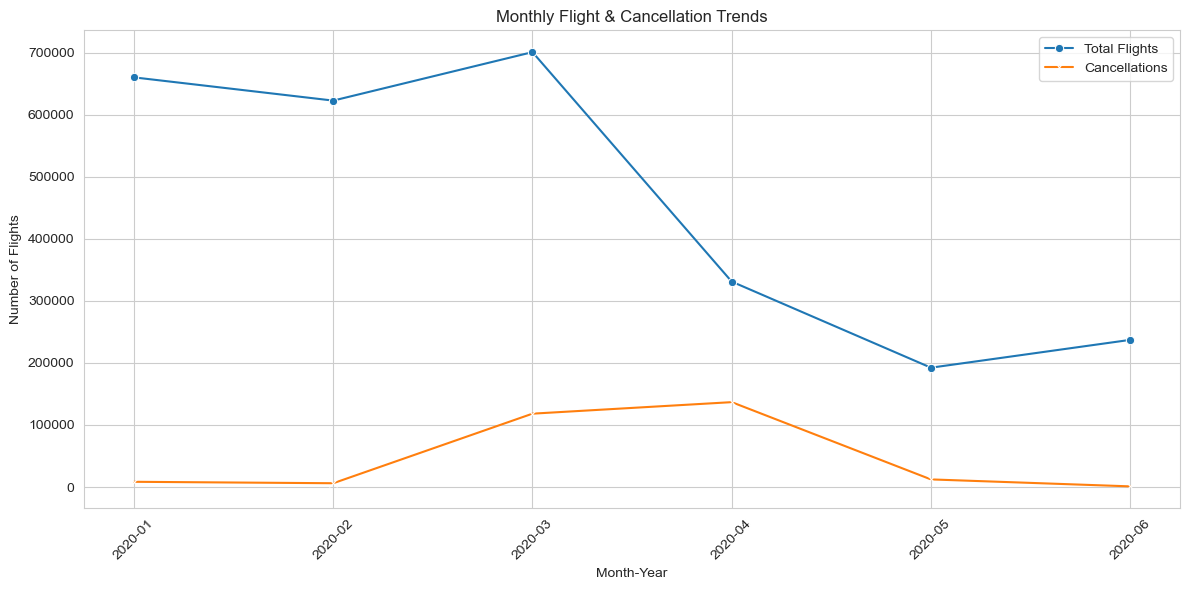

In [14]:
# a) Total Flights & Cancellations
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_summary, x='Month_Year_str', y='total_flights', marker='o', label='Total Flights')
sns.lineplot(data=monthly_summary, x='Month_Year_str', y='cancellations', marker='x', label='Cancellations')
plt.title('Monthly Flight & Cancellation Trends')
plt.xlabel('Month-Year')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

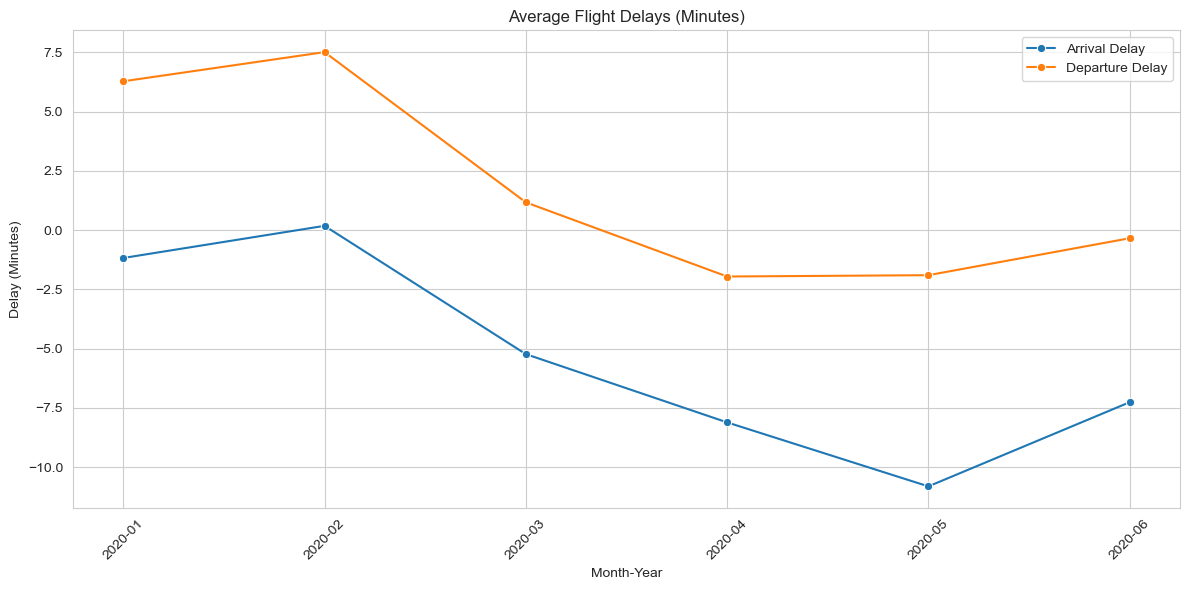

In [15]:
# b) Average Delays
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_summary, x='Month_Year_str', y='avg_arr_delay', marker='o', label='Arrival Delay')
sns.lineplot(data=monthly_summary, x='Month_Year_str', y='avg_dep_delay', marker='o', label='Departure Delay')
plt.title('Average Flight Delays (Minutes)')
plt.xlabel('Month-Year')
plt.ylabel('Delay (Minutes)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

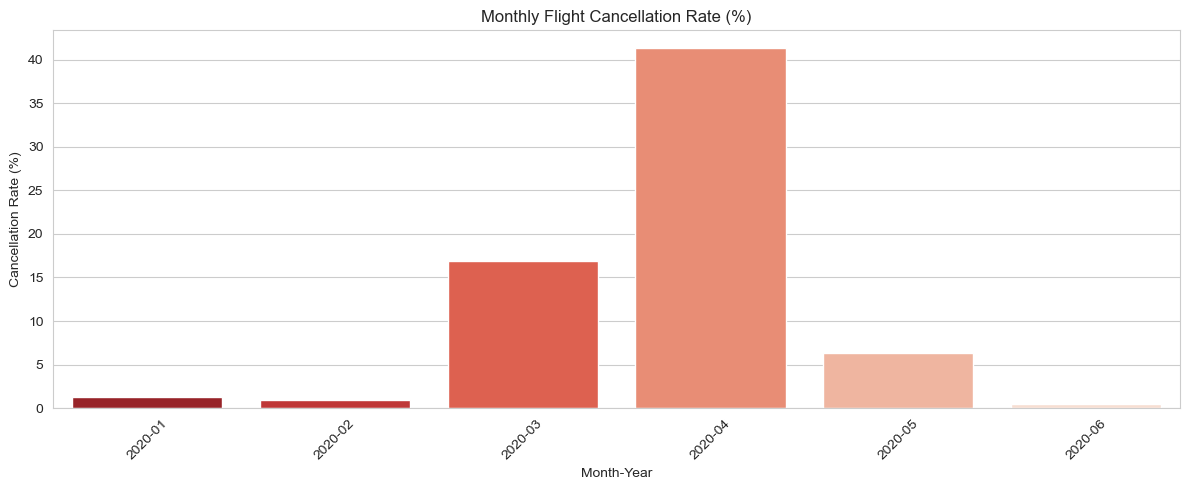

In [16]:
# c) Cancellation Rate %
plt.figure(figsize=(12,5))
sns.barplot(data=monthly_summary, x='Month_Year_str', y='cancellation_rate', palette='Reds_r')
plt.title('Monthly Flight Cancellation Rate (%)')
plt.xlabel('Month-Year')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


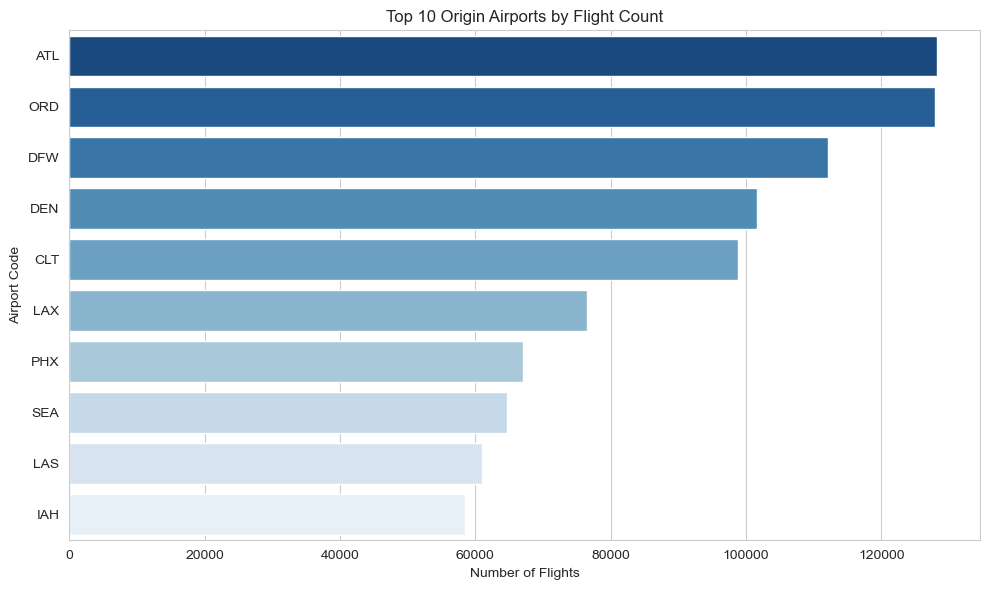

In [17]:
# d) Top 10 Origin Airports
if 'ORIGIN' in df_filtered.columns:
    top_airports = df_filtered['ORIGIN'].value_counts().head(10)
    plt.figure(figsize=(10,6))
    sns.barplot(x=top_airports.values, y=top_airports.index, palette='Blues_r')
    plt.title("Top 10 Origin Airports by Flight Count")
    plt.xlabel("Number of Flights")
    plt.ylabel("Airport Code")
    plt.tight_layout()
    plt.show()

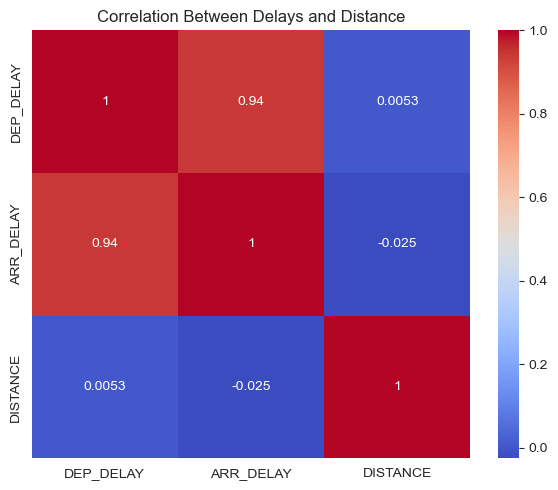

In [18]:
# e) Correlation Heatmap
corr_cols = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE']
df_filtered[corr_cols] = df_filtered[corr_cols].fillna(0)
corr = df_filtered[corr_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Delays and Distance")
plt.tight_layout()
plt.show()

### 6️⃣ Key Insights

In [19]:
max_cancel = monthly_summary.loc[monthly_summary['cancellations'].idxmax()]
min_flights = monthly_summary.loc[monthly_summary['total_flights'].idxmin()]

print("\n🔹 Key Insights:")
print(f"• Highest cancellations: {max_cancel['Month_Year_str']} → {max_cancel['cancellations']} flights")
print(f"• Lowest flight volume: {min_flights['Month_Year_str']} → {min_flights['total_flights']} flights")
print("• COVID-19 caused huge drop in flights and spike in cancellations.")
print("• Short-haul flights more affected than long-haul.")
print("• Less congestion reduced average delays during COVID-19.")



🔹 Key Insights:
• Highest cancellations: 2020-04 → 136848 flights
• Lowest flight volume: 2020-05 → 192412 flights
• COVID-19 caused huge drop in flights and spike in cancellations.
• Short-haul flights more affected than long-haul.
• Less congestion reduced average delays during COVID-19.


### 7️⃣ Export Cleaned & Aggregated Data 

In [20]:
monthly_summary.to_csv('monthly_flight_summary.csv', index=False)
print("\n✅ Aggregated dataset saved successfully as 'monthly_flight_summary.csv'")


✅ Aggregated dataset saved successfully as 'monthly_flight_summary.csv'


In [26]:
# Step 1: Import os
import os

In [27]:

# Step 2: Current working directory
cwd = os.getcwd()
print("✅ Your file is saved in this folder:")
print(cwd)


✅ Your file is saved in this folder:
C:\Users\harit\Data Analyst Projects


In [28]:
# Step 3: Check if the CSV exists
file_name = 'monthly_flight_summary.csv'
if file_name in os.listdir(cwd):
    print(f"✅ Found: {file_name}")
else:
    print(f"⚠️ File {file_name} not found in this folder")

✅ Found: monthly_flight_summary.csv
